In [160]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
import xgboost as xgb

In [161]:
lf = (
    pl.scan_csv("/Users/zipp/Desktop/programming/ml-training/data/AEP_hourly.csv")
    .rename({"Datetime": "ts", "AEP_MW": "val"})
    .with_columns(pl.col("ts").str.to_datetime(r"%Y-%m-%d %H:%M:%S"))
)
lf.collect().describe(), lf.head().collect()

(shape: (9, 3)
 ┌────────────┬────────────────────────────┬──────────────┐
 │ statistic  ┆ ts                         ┆ val          │
 │ ---        ┆ ---                        ┆ ---          │
 │ str        ┆ str                        ┆ f64          │
 ╞════════════╪════════════════════════════╪══════════════╡
 │ count      ┆ 121273                     ┆ 121273.0     │
 │ null_count ┆ 0                          ┆ 0.0          │
 │ mean       ┆ 2011-09-02 03:17:01.553025 ┆ 15499.513717 │
 │ std        ┆ null                       ┆ 2591.399065  │
 │ min        ┆ 2004-10-01 01:00:00        ┆ 9581.0       │
 │ 25%        ┆ 2008-03-17 15:00:00        ┆ 13630.0      │
 │ 50%        ┆ 2011-09-02 04:00:00        ┆ 15310.0      │
 │ 75%        ┆ 2015-02-16 17:00:00        ┆ 17200.0      │
 │ max        ┆ 2018-08-03 00:00:00        ┆ 25695.0      │
 └────────────┴────────────────────────────┴──────────────┘,
 shape: (5, 2)
 ┌─────────────────────┬─────────┐
 │ ts                  ┆ val     │

<Axes: xlabel='ts', ylabel='val'>

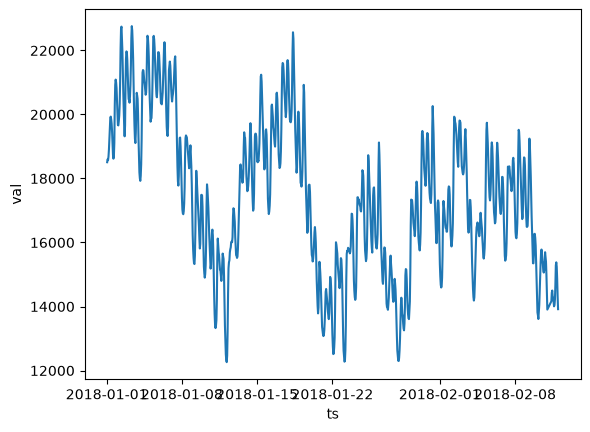

In [162]:
sns.lineplot(lf.tail(1000).collect(), x="ts", y="val")

In [163]:
def create_features(lf: pl.LazyFrame, min_year: int | None = None):
    past_values = lf.select(
        pl.col("ts").dt.offset_by("1y").alias("ts"), pl.col("val").alias("lag_1y")
    )
    diff_from_min_year = (
        pl.col("ts").dt.year() - pl.col("ts").dt.year().min()
        if min_year is None
        else pl.col("ts").dt.year() - min_year
    )
    return (
        lf.join(past_values, on="ts", how="left")
        .with_columns(
            diff_from_min_year=diff_from_min_year,
            quarter=pl.col("ts").dt.quarter(),
            month=pl.col("ts").dt.month(),
            month_sin=(pl.col("ts").dt.month() * (2 * np.pi / 12)).sin(),
            month_cos=(pl.col("ts").dt.month() * (2 * np.pi / 12)).cos(),
            weekday_sin=(pl.col("ts").dt.weekday() * (2 * np.pi / 7)).sin(),
            weekday_cos=(pl.col("ts").dt.weekday() * (2 * np.pi / 7)).cos(),
            day=pl.col("ts").dt.day(),
            hour_sin=(pl.col("ts").dt.hour() * (2 * np.pi / 24)).sin(),
            hour_cos=(pl.col("ts").dt.hour() * (2 * np.pi / 24)).cos(),
            lag_1d=pl.col("val").shift(24),
            lag_7d=pl.col("val").shift(24 * 7),
        )
        .drop("ts")
        .drop_nulls()
    )

In [164]:
YEAR = 365 * 24
lf_test = lf.tail(YEAR)
lf_val = lf.slice(-2 * YEAR, YEAR)
val_start_date = lf_val.select(pl.col("ts").min()).collect().item()
lf_train = lf.filter(pl.col("ts") < val_start_date)

In [165]:
FEATURES = [
    "diff_from_min_year",
    "quarter",
    "month",
    "month_sin",
    "month_cos",
    "weekday_sin",
    "weekday_cos",
    "day",
    "hour_sin",
    "hour_cos",
    "lag_1d",
    "lag_7d",
]
TARGET = "val"
JOIN_KEYS = [
    "diff_from_min_year",
    "quarter",
    "month",
    "day",
]
YEAR = 365 * 24
min_year = lf.select(pl.col("ts").dt.year().min()).collect().item()

lf_features = create_features(lf)
lf_test = lf_features.tail(YEAR)
lf_val = lf_features.slice(-2 * YEAR, YEAR)
val_start_date = lf.select(pl.col("ts").min()).collect().item()
lf_train = lf_features.join(lf_test, on=JOIN_KEYS, how="anti").join(
    lf_val, on=JOIN_KEYS, how="anti"
)

x_train = lf_train.select(FEATURES).collect()
x_val = lf_val.select(FEATURES).collect()
x_test = lf_test.select(FEATURES).collect()

y_train = lf_train.select(TARGET).collect().get_column(TARGET)
y_val = lf_val.select(TARGET).collect().get_column(TARGET)
y_test = lf_test.select(TARGET).collect().get_column(TARGET)

In [176]:
reg = xgb.XGBRegressor(early_stopping_rounds=50).fit(
    x_train, y_train, eval_set=((x_val, y_val),), verbose=50
)
pl.DataFrame({"feat": FEATURES, "imp": reg.feature_importances_}).sort(
    by="imp", descending=True
).head(10)#.to_pandas().plot(kind="barh", title="Importances")

[0]	validation_0-rmse:1944.29340
[50]	validation_0-rmse:952.14294
[64]	validation_0-rmse:973.21498


feat,imp
str,f32
"""lag_1d""",0.707716
"""weekday_cos""",0.111631
"""lag_7d""",0.049264
"""weekday_sin""",0.030476
"""hour_cos""",0.027618
"""quarter""",0.015093
"""month""",0.010965
"""hour_sin""",0.01096
"""month_cos""",0.009728


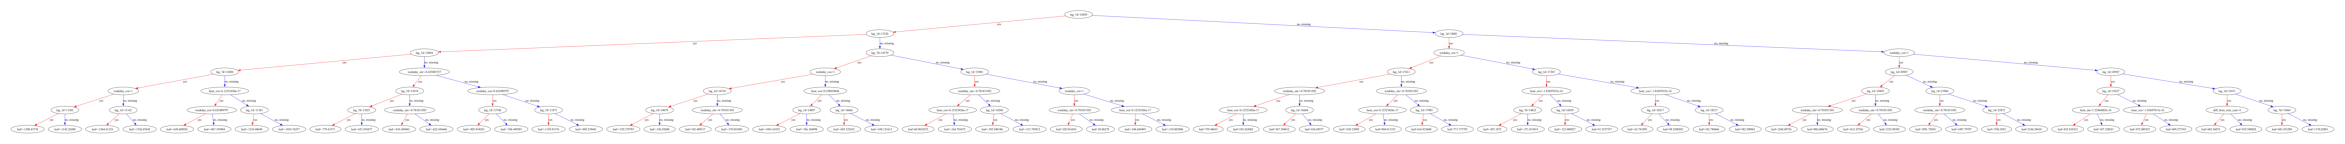

In [167]:
fig, ax = plt.subplots(figsize=(30, 10))

# 2. Pass the custom axis to XGBoost
xgb.plot_tree(reg, ax=ax)

plt.savefig("xgboost_tree.png", dpi=1000, bbox_inches="tight")
plt.show()

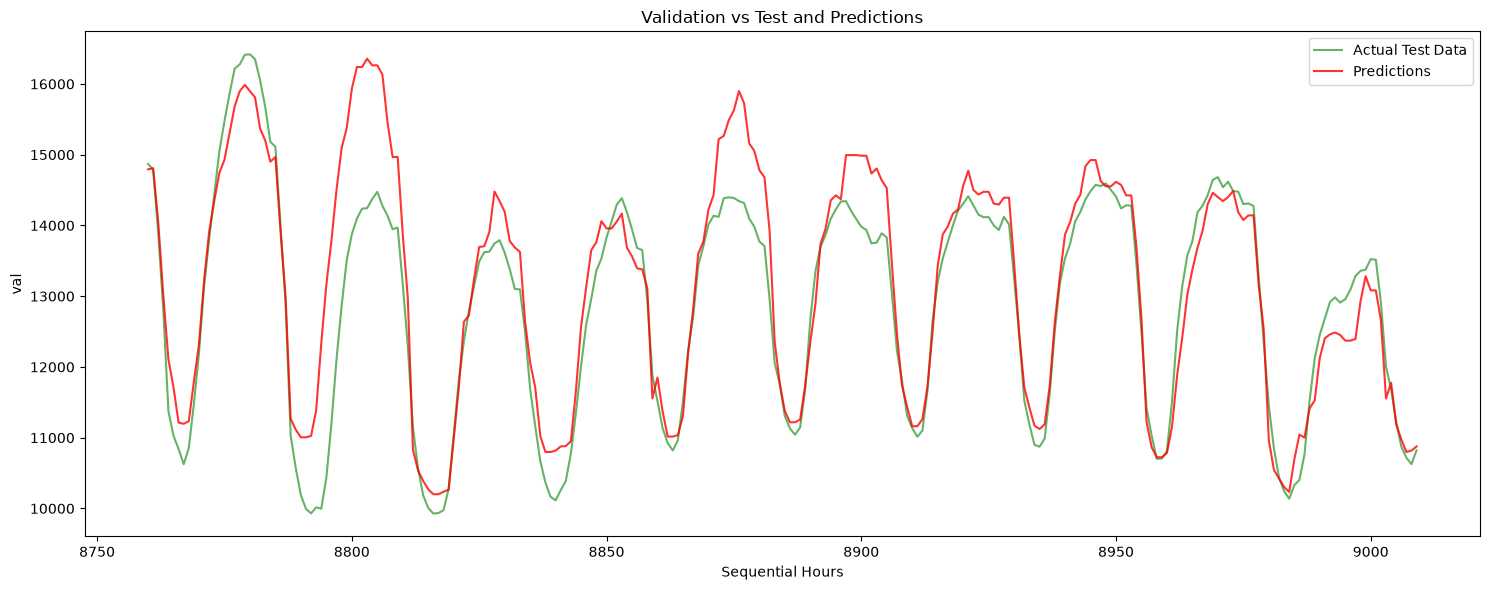

In [177]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Generate test predictions
preds = reg.predict(x_test)

# 2. Create sequential x-axes
# Validation starts at 0
x_val_idx = np.arange(len(y_val))
# Test and Predictions start exactly where Validation ends
x_test_idx = np.arange(len(y_val), len(y_val) + len(y_test))

# 3. Plot the series
plt.figure(figsize=(15, 6))

# Plot actuals
# sns.lineplot(x=x_val_idx, y=y_val, label="Validation Data", color="blue", alpha=0.6)
sns.lineplot(
    x=x_test_idx[:250],
    y=y_test[:250],
    label="Actual Test Data",
    color="green",
    alpha=0.6,
)

# Plot predictions on top of the test data
sns.lineplot(
    x=x_test_idx[:250], y=preds[:250], label="Predictions", color="red", alpha=0.8
)

plt.title("Validation vs Test and Predictions")
plt.xlabel("Sequential Hours")
plt.ylabel(TARGET)
plt.legend()
plt.tight_layout()
plt.show()

In [169]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
)

(
    root_mean_squared_error(y_test, preds),
    mean_absolute_percentage_error(y_test, preds),
    mean_absolute_error(y_test, preds),
)

(1039.5283082405965, 0.05177599053985764, 777.3554364208761)